In [1]:
!pip install kagglehub seaborn

In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import ResNet50, DenseNet121, InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
import kagglehub

path = kagglehub.dataset_download("shafiullahshafin/c-nmc-2019-dataset")
base = os.path.join(path,"C-NMC 2019 (PKG)","C-NMC_training_data")

In [7]:
def create_df(folder):
    files, labels = [], []
    for root, _, f in os.walk(folder):
        for file in f:
            if file.endswith(".bmp"):
                files.append(os.path.join(root,file))
                labels.append("leukemia" if "all" in root.lower() else "normal")
    return pd.DataFrame({"file":files,"label":labels})

df = pd.concat([
    create_df(os.path.join(base,"fold_0")),
    create_df(os.path.join(base,"fold_1")),
    create_df(os.path.join(base,"fold_2"))
]).sample(frac=1).reset_index(drop=True)

In [8]:
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"])

In [9]:
IMG = 224

train_gen = ImageDataGenerator(rescale=1./255, rotation_range=40, zoom_range=0.3, horizontal_flip=True)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_dataframe(train_df, x_col="file", y_col="label",
                                           target_size=(IMG,IMG), class_mode="binary")

val_data = val_gen.flow_from_dataframe(val_df, x_col="file", y_col="label",
                                       target_size=(IMG,IMG), class_mode="binary", shuffle=False)

print("Class Mapping:", train_data.class_indices)

Found 8528 validated image filenames belonging to 2 classes.
Found 2133 validated image filenames belonging to 2 classes.
Class Mapping: {'leukemia': 0, 'normal': 1}


In [10]:
weights = compute_class_weight('balanced',
                               classes=np.unique(train_data.classes),
                               y=train_data.classes)

class_weights = dict(enumerate(weights))
class_weights

{0: np.float64(0.7330238954787691), 1: np.float64(1.5728513463666545)}

In [10]:
def build_model(base):
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256,activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(1,activation='sigmoid')(x)

    model = Model(base.input,out)
    model.compile(optimizer=Adam(0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [11]:
resnet = build_model(ResNet50(weights='imagenet', include_top=False, input_shape=(IMG,IMG,3)))
densenet = build_model(DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG,IMG,3)))



I0000 00:00:1775722330.540250      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775722330.546381      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
resnet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 24,059,393 (91.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [13]:
densenet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 7,216,513 (27.53 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [15]:
inception = build_model(
    InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
inception.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,327,585 (85.17 MB)

 Trainable params: 22,293,153 (85.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [18]:
resnet.fit(train_data, validation_data=val_data, epochs=20, class_weight=class_weights)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1775654456.717692     234 service.cc:152] XLA service 0x7e050c006970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775654456.717728     234 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775654456.717732     234 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775654462.526235     234 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775654486.661242     234 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


267/267 ━━━━━━━━━━━━━━━━━━━━ 314s 953ms/step - accuracy: 0.7734 - loss: 0.4943 - val_accuracy: 0.3179 - val_loss: 0.9552
Epoch 2/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 125s 468ms/step - accuracy: 0.8808 - loss: 0.2945 - val_accuracy: 0.7656 - val_loss: 0.6512
Epoch 3/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 119s 446ms/step - accuracy: 0.9033 - loss: 0.2587 - val_accuracy: 0.6821 - val_loss: 0.6168
Epoch 4/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 119s 446ms/step - accuracy: 0.9118 - loss: 0.2291 - val_accuracy: 0.7431 - val_loss: 0.6873
Epoch 5/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 120s 450ms/step - accuracy: 0.9147 - loss: 0.2128 - val_accuracy: 0.7539 - val_loss: 0.7006
Epoch 6/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 125s 468ms/step - accuracy: 0.9304 - loss: 0.1882 - val_accuracy: 0.5265 - val_loss: 1.7815
Epoch 7/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 120s 449ms/step - accuracy: 0.9282 - loss: 0.1965 - val_accuracy: 0.7909 - val_loss: 0.5722
Epoch 8/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 119s 443ms/step - accuracy: 0.9404 - loss: 0.16

In [19]:
resnet.save("/kaggle/working/resnet_base.h5")


In [20]:
densenet.fit(train_data, validation_data=val_data, epochs=20, class_weight=class_weights)


Epoch 1/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 427s 981ms/step - accuracy: 0.7693 - loss: 0.4956 - val_accuracy: 0.8092 - val_loss: 0.4249
Epoch 2/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 128s 477ms/step - accuracy: 0.8748 - loss: 0.3150 - val_accuracy: 0.6573 - val_loss: 0.8130
Epoch 3/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 121s 453ms/step - accuracy: 0.8912 - loss: 0.2628 - val_accuracy: 0.9058 - val_loss: 0.2455
Epoch 4/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 121s 453ms/step - accuracy: 0.9024 - loss: 0.2492 - val_accuracy: 0.7557 - val_loss: 0.5783
Epoch 5/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 122s 458ms/step - accuracy: 0.9140 - loss: 0.2122 - val_accuracy: 0.9405 - val_loss: 0.1502
Epoch 6/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 121s 452ms/step - accuracy: 0.9294 - loss: 0.2003 - val_accuracy: 0.8622 - val_loss: 0.3270
Epoch 7/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 122s 457ms/step - accuracy: 0.9402 - loss: 0.1732 - val_accuracy: 0.9362 - val_loss: 0.1633
Epoch 8/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 124s 462ms/step - accuracy: 0.9330 -

In [27]:
densenet.save("/kaggle/working/densenet_base.h5")


In [41]:
inception.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weights
)

Epoch 1/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 120s 449ms/step - accuracy: 0.8996 - loss: 0.3150 - val_accuracy: 0.7609 - val_loss: 0.5828
Epoch 2/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 117s 438ms/step - accuracy: 0.9187 - loss: 0.2761 - val_accuracy: 0.8687 - val_loss: 0.4625
Epoch 3/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 118s 439ms/step - accuracy: 0.9289 - loss: 0.2445 - val_accuracy: 0.8884 - val_loss: 0.3741
Epoch 4/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 116s 433ms/step - accuracy: 0.9342 - loss: 0.2392 - val_accuracy: 0.8359 - val_loss: 0.4366
Epoch 5/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 119s 445ms/step - accuracy: 0.9441 - loss: 0.1966 - val_accuracy: 0.9034 - val_loss: 0.2347
Epoch 6/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 113s 421ms/step - accuracy: 0.9402 - loss: 0.2014 - val_accuracy: 0.8889 - val_loss: 0.4273
Epoch 7/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 114s 426ms/step - accuracy: 0.9468 - loss: 0.1949 - val_accuracy: 0.8959 - val_loss: 0.3596
Epoch 9/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 113s 424ms/step - accuracy: 0.9568 -

In [43]:
inception.save("/kaggle/working/inception_base.h5")

67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step

ResNet  Accuracy: 0.870604781997187
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1455
           1       0.88      0.69      0.77       678

    accuracy                           0.87      2133
   macro avg       0.87      0.82      0.84      2133
weighted avg       0.87      0.87      0.87      2133



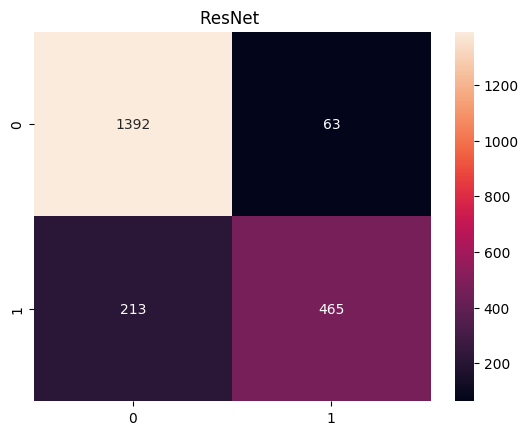

67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step

DenseNet  Accuracy: 0.7885607126113455
              precision    recall  f1-score   support

           0       0.92      0.76      0.83      1455
           1       0.62      0.86      0.72       678

    accuracy                           0.79      2133
   macro avg       0.77      0.81      0.78      2133
weighted avg       0.82      0.79      0.80      2133



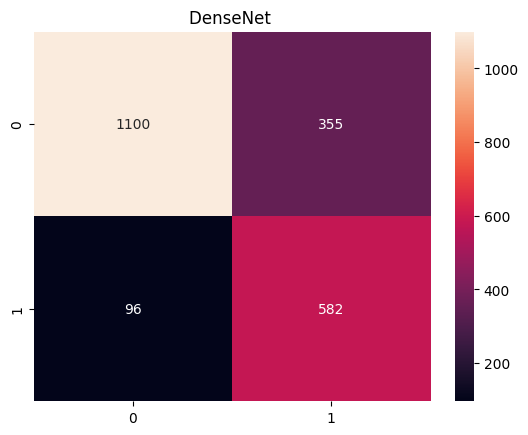

67/67 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step

Inception  Accuracy: 0.9104547585560244
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1455
           1       0.95      0.76      0.84       678

    accuracy                           0.91      2133
   macro avg       0.92      0.87      0.89      2133
weighted avg       0.91      0.91      0.91      2133



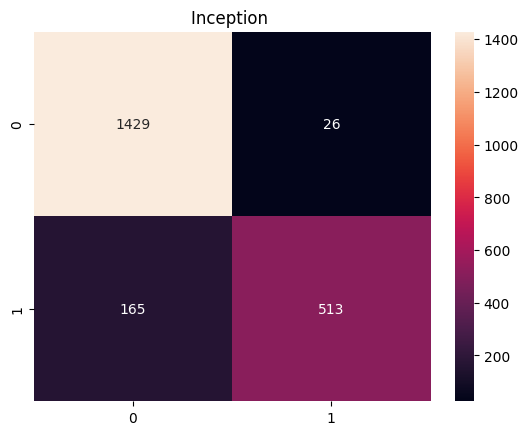

In [44]:
def evaluate(model, name):
    pred = model.predict(val_data)
    pred_label = (pred > 0.5).astype(int)

    print(f"\n{name} Accuracy:", accuracy_score(val_data.classes, pred_label))
    print(classification_report(val_data.classes, pred_label))

    cm = confusion_matrix(val_data.classes, pred_label)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name)
    plt.show()
evaluate(resnet,"ResNet ")
evaluate(densenet,"DenseNet ")
evaluate(inception, "Inception ")

In [9]:
from tensorflow.keras.models import Model , load_model

resnet = load_model("/kaggle/input/models/freakyboy17/models/tensorflow2/default/1/resnet_base.h5")
densenet = load_model("/kaggle/input/models/freakyboy17/models/tensorflow2/default/1/densenet_base.h5")
inception = load_model("/kaggle/input/models/freakyboy17/models/tensorflow2/default/1/inception_base.h5")

meta_model = load_model("/kaggle/input/models/freakyboy17/models/tensorflow2/default/1/meta_model.h5")

I0000 00:00:1775732580.273193      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775732580.279118      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [69]:
p1 = resnet.predict(val_data)
p2 = densenet.predict(val_data)
p3 = inception.predict(val_data)

y_true = val_data.classes

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


67/67 ━━━━━━━━━━━━━━━━━━━━ 40s 501ms/step
67/67 ━━━━━━━━━━━━━━━━━━━━ 39s 323ms/step
67/67 ━━━━━━━━━━━━━━━━━━━━ 24s 205ms/step


In [12]:
h1 = (p1 > 0.5).astype(int)
h2 = (p2 > 0.5).astype(int)
h3 = (p3 > 0.5).astype(int)

hard = ((h1 + h2 + h3) >= 2).astype(int)

print("Hard Voting Accuracy:", accuracy_score(y_true, hard))
hard = hard.astype(int)

print("\n🔴 HARD VOTING REPORT")
print(classification_report(y_true, hard))

Hard Voting Accuracy: 0.929676511954993

🔴 HARD VOTING REPORT
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1455
           1       0.95      0.83      0.88       678

    accuracy                           0.93      2133
   macro avg       0.93      0.90      0.92      2133
weighted avg       0.93      0.93      0.93      2133



In [15]:
soft = (p1 + p2 + p3) / 3
soft = (soft > 0.5).astype(int)
print("Soft Voting Accuracy:", accuracy_score(y_true, soft))
soft = soft.astype(int)

print("\n🟢 SOFT VOTING REPORT")
print(classification_report(y_true, soft))


Soft Voting Accuracy: 0.9329582747304266

🟢 SOFT VOTING REPORT
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1455
           1       0.96      0.82      0.89       678

    accuracy                           0.93      2133
   macro avg       0.94      0.90      0.92      2133
weighted avg       0.93      0.93      0.93      2133



In [70]:
X_meta = np.concatenate([p1, p2, p3], axis=1).astype(np.float32)

y_true = np.array(val_data.classes).astype(np.float32)
y_true = y_true.reshape(-1, 1)

inp = Input(shape=(3,))
x = Dense(16, activation='relu')(inp)
out = Dense(1, activation='sigmoid')(x)

meta_model = Model(inp, out)

meta_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
meta_model.fit(X_meta, y_true, epochs=20, batch_size=32)

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7669 - loss: 0.6681
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9200 - loss: 0.5698
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9269 - loss: 0.4656
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9261 - loss: 0.3767
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9170 - loss: 0.3214
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9212 - loss: 0.2652
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9322 - loss: 0.2273
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9242 - loss: 0.2234
Epoch 9/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9314 - loss: 0.2042
Epoch 10/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9236 - loss: 0.2112
Epoch 11/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9279 - loss: 0.1996
Epoch 12/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9310 - l

In [71]:

meta_pred = meta_model.predict(X_meta)
meta_label = (meta_pred>0.5).astype(int)
print("Learnable Ensemble Accuracy:", accuracy_score(y_true, meta_label))
print("\n🔵 LEARNABLE ENSEMBLE REPORT")
print(classification_report(y_true, meta_label))
meta_model.save("/kaggle/working/ensemble_model.h5")

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Learnable Ensemble Accuracy: 0.9292076887013596

🔵 LEARNABLE ENSEMBLE REPORT
              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95      1455
         1.0       0.93      0.84      0.88       678

    accuracy                           0.93      2133
   macro avg       0.93      0.90      0.92      2133
weighted avg       0.93      0.93      0.93      2133



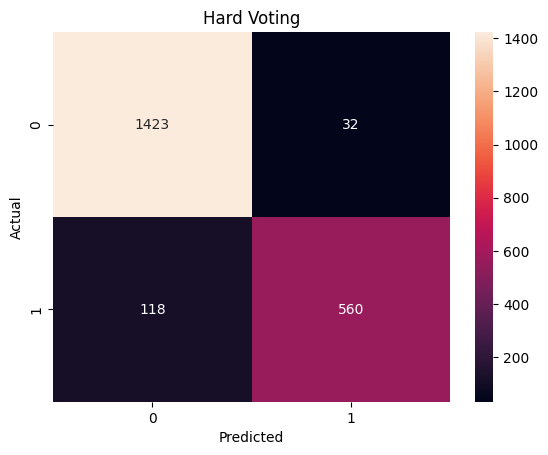

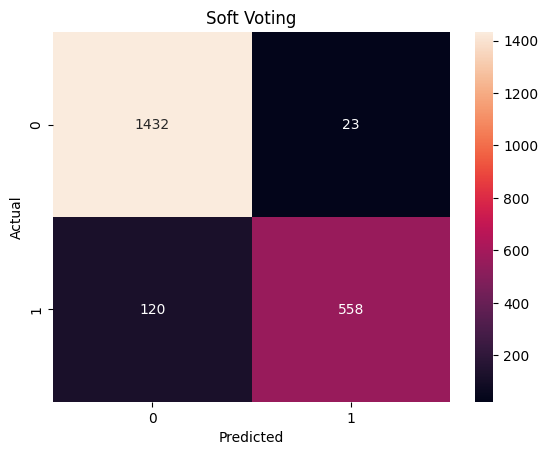

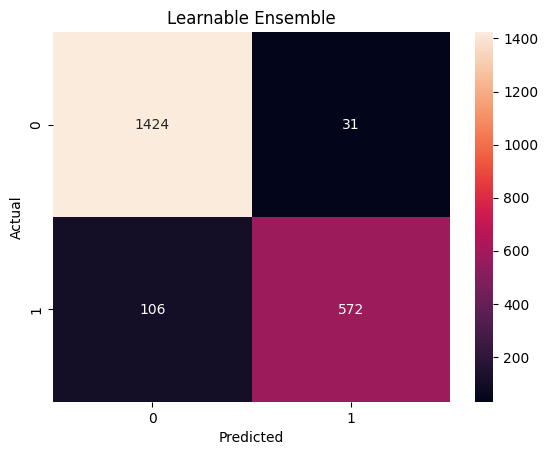

In [23]:
def plot_cm(true, pred, title):
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_true, hard, "Hard Voting")
plot_cm(y_true, soft, "Soft Voting")
plot_cm(y_true, meta_label, "Learnable Ensemble")

In [53]:
meta_model.save("/kaggle/working/meta_model.h5")

In [14]:
def gradcam(model, img_array):

    import tensorflow as tf
    import numpy as np

    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
            break

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        loss = tf.math.log(predictions + 1e-8)

    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        return np.zeros((224,224))

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)

    heatmap = np.maximum(heatmap, 0)

    if np.max(heatmap) == 0:
        return np.zeros((224,224))

    heatmap = heatmap / np.max(heatmap)

    return heatmap

In [1]:
from tensorflow.keras.models import Model , load_model

resnet = load_model("/kaggle/input/models/freakyboy17/models/tensorflow2/default/1/resnet_base.h5")
densenet = load_model("/kaggle/input/models/freakyboy17/models/tensorflow2/default/1/densenet_base.h5")
inception = load_model("/kaggle/input/models/freakyboy17/models/tensorflow2/default/1/inception_base.h5")

meta_model = load_model("/kaggle/input/models/freakyboy17/models/tensorflow2/default/1/meta_model.h5")

2026-04-10 10:43:56.424279: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775817836.573150      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775817836.620884      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775817836.997394      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775817836.997433      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775817836.997436      55 computation_placer.cc:177] computation placer alr

In [11]:
class_indices = {'leukemia': 0, 'normal': 1}
inv_map = {0: 'leukemia', 1: 'normal'}

In [12]:
def predict_full(img_path):

    img = load_img(img_path, target_size=(224,224))
    img_array = img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    r = resnet.predict(img_array)
    d = densenet.predict(img_array)
    i = inception.predict(img_array)

    hard = int(((r>0.5) + (d>0.5) + (i>0.5)) >= 2)

    soft = int(((r+d+i)/3) > 0.5)

    X = np.concatenate([r,d,i], axis=1)
    meta = meta_model.predict(X)
    meta_label = int(meta > 0.5)

    print("\n🔍 MODEL OUTPUTS")
    print("ResNet:", r[0][0])
    print("DenseNet:", d[0][0])
    print("Inception:", i[0][0])

    print("\n⚙️ ENSEMBLE RESULTS")
    print("Hard Voting:", hard)
    print("Soft Voting:", soft)
    print("Learnable Ensemble:", meta_label)

    mapping = train_data.class_indices
    inv = {v:k for k,v in mapping.items()}

    print("\n✅ FINAL PREDICTION:", inv[meta_label])

    plt.imshow(img)
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

    heatmap = gradcam(resnet, img_array)

    heatmap = cv2.resize(heatmap,(224,224))
    heatmap = np.uint8(255*heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    img_cv = cv2.imread(img_path)
    img_cv = cv2.resize(img_cv,(224,224))

    superimposed = heatmap*0.4 + img_cv

    plt.imshow(cv2.cvtColor(superimposed.astype('uint8'), cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM (ResNet)")
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

🔍 MODEL OUTPUTS
ResNet: 0.0056088716
DenseNet: 0.99059266
Inception: 0.17108288

⚙️ ENSEMBLE RESULTS
Hard Voting: 0
Soft Voting: 0
Learnable Ensemble: 0

✅ FINAL PREDICTION: leukemia


/tmp/ipykernel_55/1013236135.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  hard = int(((r>0.5) + (d>0.5) + (i>0.5)) >= 2)
/tmp/ipykernel_55/1013236135.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  soft = int(((r+d+i)/3) > 0.5)
/tmp/ipykernel_55/1013236135.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  meta_label = int(meta > 0.5)


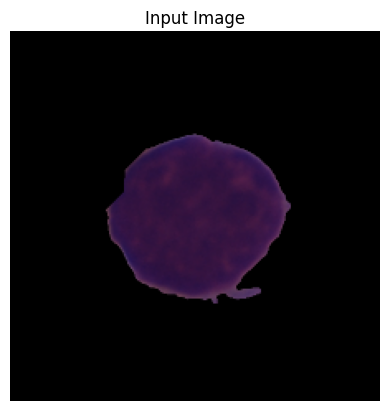

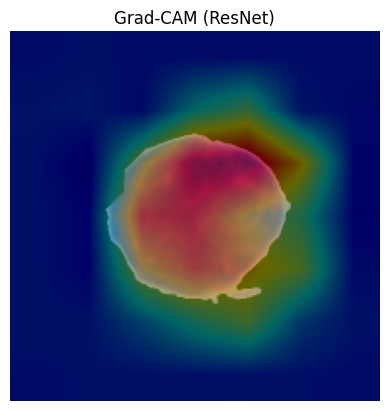

In [27]:
predict_full("/kaggle/input/datasets/shafiullahshafin/c-nmc-2019-dataset/C-NMC 2019 (PKG)/C-NMC_test_prelim_phase_data/1059.bmp")